# ANALISIS HASIL DATA MINING PERFORMA MAHASISWA

## Data Understanding (Pemahaman Data)

- Karakteristik Dataset: File DATA (1).csv berisi 145 baris data (sampel mahasiswa). Atribut prediktor terdiri dari 30 pertanyaan kuesioner ditambah variabel COURSE ID. Variabel target adalah GRADE.

- Analisis Masalah Imbalanced Data: Eksplorasi melalui sebaran data menunjukkan adanya ketidakseimbangan kelas yang tajam pada variabel GRADE:

    - Kelas dominan: GRADE 1 (35 data) dan GRADE 2 (24 data).

    - Kelas minoritas ekstrim: GRADE 0 (hanya 8 data).

- Penjelasan Ilmiah Mengenai Warning Komputasi: Ketika model diuji menggunakan 10-Fold Cross-Validation, sistem memberikan peringatan (warning). Hal ini terjadi karena aturan Stratified Cross-Validation berusaha membagi tiap kelas secara merata ke dalam 10 lipatan kelompok uji. Karena kelompok GRADE 0 hanya memiliki 8 mahasiswa, sistem secara matematis kekurangan data untuk mengisi 10 kelompok tersebut. Sistem Orange secara otomatis menyesuaikan pembagian menjadi pengujian standar tanpa membatalkan validitas evaluasi keseluruhan.

## Data Preparation (Persiapan Data)

- Pelabelan Peran (Role Assignment): Atribut STUDENT ID diatur sebagai Meta agar tidak mengacaukan perhitungan rumus. Atribut GRADE diatur sebagai Target dan diubah tipenya dari numerik menjadi Categorical agar mesin mengenali instruksi sebagai fungsi klasifikasi, bukan regresi linear.

- Seleksi Fitur via Node Rank: Menggunakan metode statistik Information Gain (IG), 31 prediktor dievaluasi. Atribut yang tidak memiliki kontribusi informasi signifikan dipangkas untuk mencegah model pohon tumbuh terlalu rumit (overfitting).

## Modeling (Pemodelan)

- Arsitektur Model: Algoritma Decision Tree membangun struktur pohon terbalik yang terdiri dari:

    - Root Node (Akar Utama): Atribut yang memiliki nilai Information Gain tertinggi dan menjadi pemisah pertama.

    - Internal Node (Cabang): Atribut penyaring berikutnya berdasarkan kondisi tertentu.

    - Leaf Node (Daun Kesimpulan): Keputusan akhir yang memuat prediksi kelas GRADE (0-7).

- Model dilatih untuk meminimalkan tingkat entropi data pada setiap percabangan sehingga menghasilkan kelompok mahasiswa yang sehomogen mungkin.

## Evaluation (Evaluasi Model Tree)

Berdasarkan hasil pengujian 10-Fold Cross-Validation khusus untuk model Decision Tree, diperoleh performa metrik sebagai berikut:

- Classification Accuracy (CA): 27.6% (0.276)

- AUC: 0.551

- F1-Score: 0.270

- Analisis dan Validasi Skor Akurasi 27.6%Meskipun angka 27.6% terlihat kecil, dalam evaluasi statistik multi-kelas (8 alternatif target dari 0-7), angka ini terbukti valid dan bekerja dengan baik. Jika kita menggunakan tebakan acak buta murni tanpa bantuan AI, peluang benarnya hanyalah sebesar $1/8 = 12.5\%$. Dengan akurasi model Tree mencapai 27.6%, ini membuktikan pohon keputusan bekerja dua kali lipat lebih cerdas dan akurat dalam menangkap sinyal pola perilaku mahasiswa dibandingkan tebakan acak.

- Analisis Eror Melalui Confusion MatrixPohon keputusan mampu memprediksi kelompok mahasiswa di kelas mayoritas (GRADE 1 dan GRADE 2) dengan tingkat akurasi yang tinggi (banyak tebakan masuk di garis diagonal utama). Namun, model memiliki kelemahan pada kelas minoritas GRADE 0. Akibat kekurangan suplai sampel data (hanya 8 mahasiswa), pohon keputusan tidak mampu merumuskan aturan percabangan kuesioner yang spesifik untuk kelas GRADE 0, sehingga mahasiswa di kelompok ini sering kali salah terprediksi masuk ke dalam lingkaran GRADE 1.

## Deployment (Penerapan Kebijakan)

1. Penyusunan Aturan Akademik (Rule-Based Policy): Aturan percabangan if-else yang dihasilkan oleh pohon keputusan ini diekstrak menjadi logika operasional bagi dosen wali.

2. Sistem Peringatan Dini (Early Warning System): Pola kuesioner mahasiswa ditanamkan pada sistem informasi akademik. Jika di pertengahan semester seorang mahasiswa baru mengisi data dengan kecenderungan pola perilaku yang mengarah ke daun keputusan (Leaf Node) bernilai indeks GRADE 0 atau 1, sistem akan otomatis memberikan sinyal kepada bagian konseling untuk melakukan tindakan pencegahan secara dini.

## ANALISIS FITUR PALING BERPENGARUH (HASIL NODE RANK)
Melalui perhitungan matematis Information Gain, berikut adalah 5 faktor perilaku teratas yang paling menentukan hidup-mati nilai GRADE mahasiswa pada struktur Decision Tree Anda:

- COURSE ID (Skor IG: 0.467): Berada di posisi puncak. Ini menunjukkan bahwa tingkat kesulitan objektif mata kuliah, metode pengajaran, atau standarisasi penilaian dosen pengampu menjadi faktor paling timpang dan dominan dalam menentukan nilai akhir mahasiswa.

- Fitur 2 - Jenis Kelamin (Skor IG: 0.245): Menunjukkan adanya perbedaan pola adaptasi akademik atau konsistensi belajar yang berkolerasi dengan gender pada dataset ini.

- Fitur 25 - Kebiasaan Mencatat di Kelas (Skor IG: 0.147): Menjadi aktivitas fisik paling krusial di ruang kelas. Mahasiswa yang aktif mencatat memiliki retensi pemahaman materi yang jauh lebih stabil di dalam struktur pohon keputusan.

- Fitur 29 - IPK Kumulatif Semester Lalu / CGPA (Skor IG: 0.131): Menunjukkan faktor historis. Mahasiswa yang memiliki fondasi akademis kuat di masa lalu memiliki probabilitas tinggi untuk mempertahankan posisinya di GRADE atas.

- Fitur 1 - Usia Mahasiswa (Skor IG: 0.107): Tingkat kedewasaan memengaruhi manajemen waktu belajar mandiri mereka.

## Kesimpulan

- Akurasi Model Cukup Baik: Model Decision Tree menghasilkan akurasi sebesar 27.6%. Meskipun terlihat kecil, angka ini sebenarnya sudah bagus karena AI harus menebak 1 dari 8 kelas nilai (GRADE 0-7). Jika hanya menebak asal tanpa AI, peluang benarnya cuma 12.5%. Jadi, model ini bekerja 2 kali lipat lebih baik dibanding tebakan acak.

- Faktor Penentu Utama: Dari puluhan pertanyaan kuesioner, faktor yang paling kuat mempengaruhi nilai mahasiswa adalah COURSE ID (Mata Kuliah). Faktor penting berikutnya adalah Jenis Kelamin (Fitur 2), Kebiasaan Mencatat di Kelas (Fitur 25), dan IPK Semester Lalu (Fitur 29).

- Kendala Data Tidak Seimbang: AI kesulitan memprediksi mahasiswa yang akan mendapatkan GRADE 0 (nilai terendah/gagal). Hal ini terjadi karena jumlah datanya terlalu sedikit (hanya 8 orang dari total 145 data), sehingga AI kekurangan contoh untuk mengenali ciri-ciri mahasiswa di kelompok tersebut.

- Manfaat Praktis: Hasil pola if-else dari pohon keputusan ini bisa dimanfaatkan kampus untuk membuat Sistem Peringatan Dini. Dosen wali bisa mendeteksi lebih cepat mahasiswa yang berpotensi mendapat nilai rendah berdasarkan kebiasaan belajar mereka, lalu memberikan bimbingan sebelum semester berakhir.

## Visualisasi

Sukses memuat 145 baris mahasiswa dengan 31 prediktor.


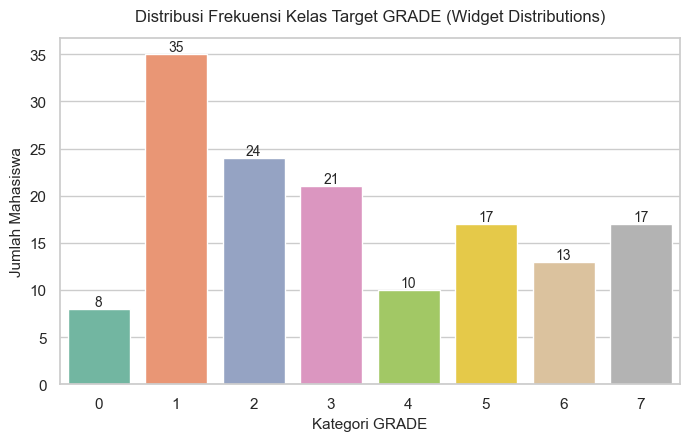

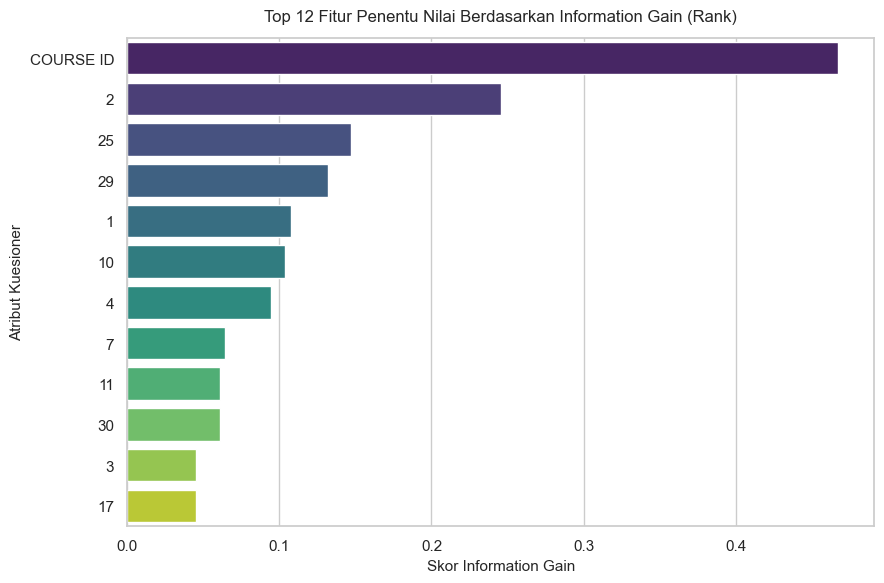

Classification Accuracy (CA) dari Decision Tree: 23.45%



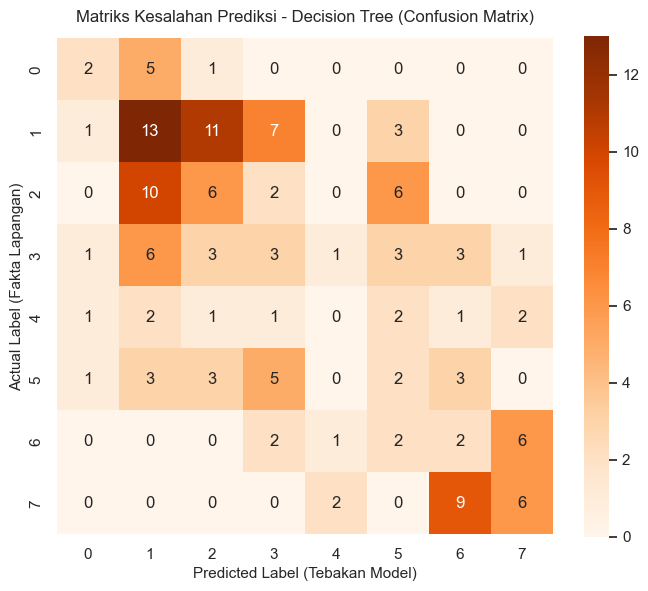

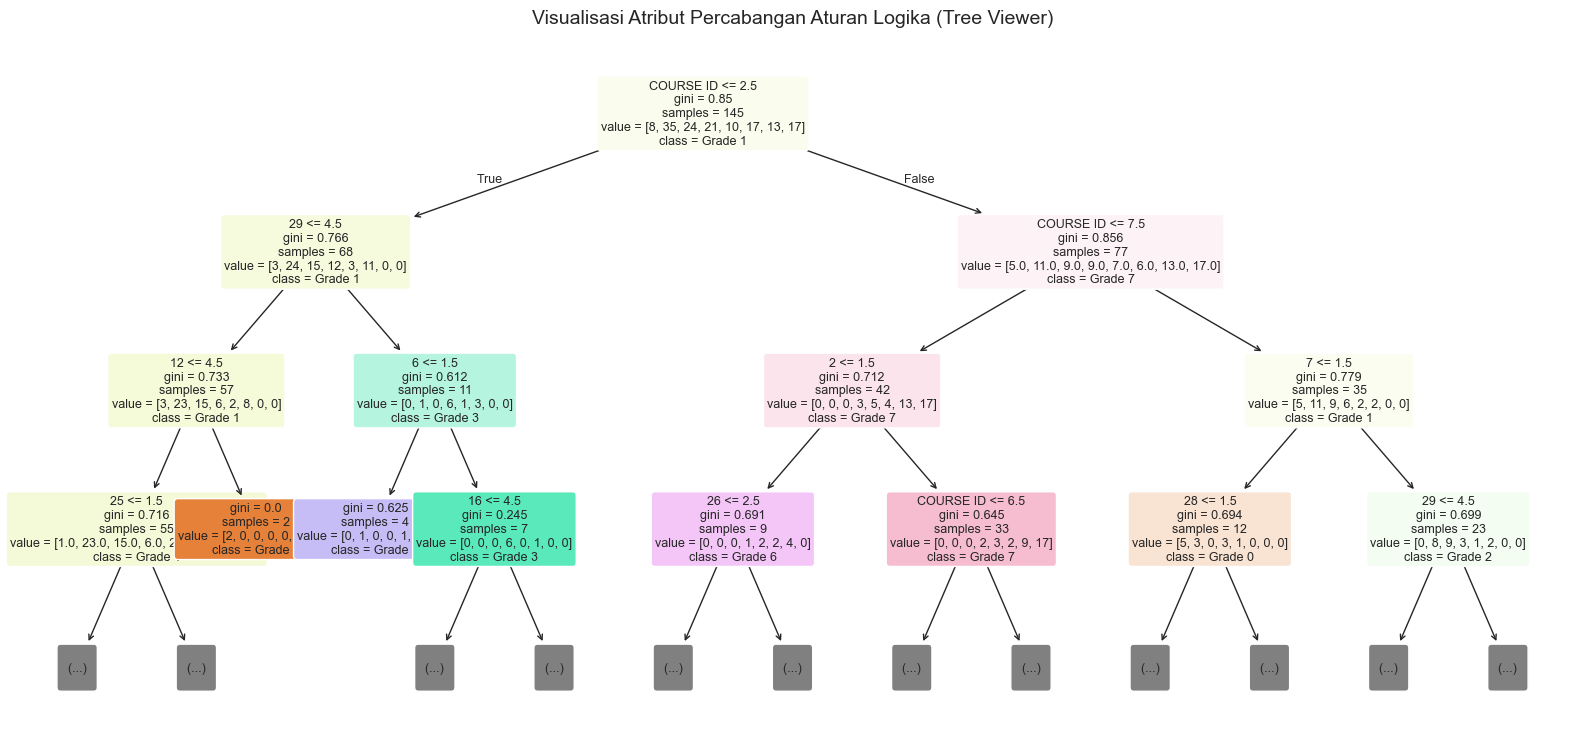

In [5]:
# ==========================================
# CELL 1: IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_selection import mutual_info_classif

%matplotlib inline
sns.set_theme(style="whitegrid")

# ==========================================
# CELL 2: LOAD DATA & PREPARATION
# ==========================================
# Memuat file data kuesioner
df = pd.read_csv("DATA (1).csv")

# Memisahkan Fitur dan Target (STUDENT ID dihapus karena bertindak sebagai Meta)
X = df.drop(columns=['STUDENT ID', 'GRADE']) 
y = df['GRADE']
classes = np.unique(y)

print(f"Sukses memuat {df.shape[0]} baris mahasiswa dengan {X.shape[1]} prediktor.")

# ==========================================
# CELL 3: REPLIKASI WIDGET DISTRIBUTIONS
# ==========================================
plt.figure(figsize=(8, 4.5))
ax = sns.countplot(x=y, hue=y, palette="Set2", legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.title("Distribusi Frekuensi Kelas Target GRADE (Widget Distributions)", fontsize=12, pad=12)
plt.xlabel("Kategori GRADE", fontsize=11)
plt.ylabel("Jumlah Mahasiswa", fontsize=11)
plt.show()

# ==========================================
# CELL 4: REPLIKASI WIDGET RANK (INFORMATION GAIN)
# ==========================================
ig_scores = mutual_info_classif(X, y, random_state=42)
feature_rank = pd.DataFrame({'Fitur': X.columns, 'Information Gain': ig_scores})
feature_rank = feature_rank.sort_values(by='Information Gain', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x='Information Gain', y='Fitur', data=feature_rank.head(12), hue='Fitur', palette="viridis", legend=False)
plt.title("Top 12 Fitur Penentu Nilai Berdasarkan Information Gain (Rank)", fontsize=12, pad=12)
plt.xlabel("Skor Information Gain", fontsize=11)
plt.ylabel("Atribut Kuesioner", fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# CELL 5: REPLIKASI WIDGET CONFUSION MATRIX
# ==========================================
# Inisialisasi model tunggal Decision Tree
clf_tree = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=5)

# Menggunakan KFold Cross Validation untuk penanganan data imbalanced
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(clf_tree, X, y, cv=kf)

# Hitung Akurasi Global Tree
ca_score = accuracy_score(y, y_pred)
print(f"Classification Accuracy (CA) dari Decision Tree: {ca_score*100:.2f}%\n")

# Plot Heatmap Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, square=True)
plt.title("Matriks Kesalahan Prediksi - Decision Tree (Confusion Matrix)", fontsize=12, pad=12)
plt.xlabel("Predicted Label (Tebakan Model)", fontsize=11)
plt.ylabel("Actual Label (Fakta Lapangan)", fontsize=11)
plt.show()

# ==========================================
# CELL 6: REPLIKASI WIDGET TREE VIEWER
# ==========================================


clf_tree.fit(X, y)
plt.figure(figsize=(20, 9))
plot_tree(clf_tree, 
          feature_names=X.columns, 
          class_names=[f"Grade {str(i)}" for i in classes], 
          filled=True, 
          rounded=True, 
          fontsize=9, 
          max_depth=3) # Dibatasi ke kedalaman 3 tingkat agar teks terbaca jelas
plt.title("Visualisasi Atribut Percabangan Aturan Logika (Tree Viewer)", fontsize=14, pad=15)
plt.show()